# Plotting and Calibrating Geoprecision Thermistor chain data

This notebook provides a workflow for plotting and calibrating thermistor chain data from glacier boreholes and calibration experiments. It uses custom modules for data processing and visualization.

## Import required Libraries and Modules

In [1]:
import sys
import os

# Add project root to Python path
project_root = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt

# Import custom modules
from processing.thermistor_processing import *
from calibration.thermistor_calibration import *

In [2]:
# root dir
root_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/"

# set main calibration data dir
cal_dir = root_dir + "thermistor_chains/calibration_data/"

# set chain calibration dir
A551FD_dir = cal_dir + "A551FD/raw/"
A551FE_dir = cal_dir + "A551FE/raw/"
A55200_dir = cal_dir + "A55200/raw/"
A55201_dir = cal_dir + "A55201/raw/"
A55202_dir = cal_dir + "A55202/raw/"
A55203_dir = cal_dir + "A55203/raw/"
A55204_dir = cal_dir + "A55204/raw/"
A55205_dir = cal_dir + "A55205/raw/"

# set maximum measurement depths
A551FE_depth = 45.0 # AH1 -> borehole depth is 50.6m
A55204_depth = 20.3 # AH2
A55205_depth = 18.3 # AH3 -> borehole depth is 58.3m
A551FD_depth = 29.0 # HL1
A55203_depth = 21.5 # HL2 
A55200_depth = 21.5 # HL3
A55201_depth = 38.3 # CH1
A55202_depth = 17.0 # CH2

# generate calibration data objects
A551FE_cal_data = ThermistorData(A551FE_dir + "A551FE_20250729123855.csv",",",A551FE_depth)   
A55204_cal_data = ThermistorData(A55204_dir + "A55204_20250729123756.csv",",",A55204_depth)   
A55205_cal_data = ThermistorData(A55205_dir + "A55205_20250729123810.csv",",",A55205_depth)   
A551FD_cal_data = ThermistorData(A551FD_dir + "A551FD_20250729123824.csv",",",A551FD_depth)
A55203_cal_data = ThermistorData(A55203_dir + "A55203_20250729123726.csv",",",A55203_depth)   
A55200_cal_data = ThermistorData(A55200_dir + "A55200_20250729123642.csv",",",A55200_depth)   
A55201_cal_data = ThermistorData(A55201_dir + "A55201_20250729123655.csv",",",A55201_depth)   
A55202_cal_data = ThermistorData(A55202_dir + "A55202_20250729123712.csv",",",A55202_depth)   


## Load thermistor chain data

In [3]:
# get calibration data for each thermistor chain
A551FD_cal_df = A551FD_cal_data.get_chain_data('28.07.2025 13:30:00','28.07.2025 14:30:00')
A551FE_cal_df = A551FE_cal_data.get_chain_data('28.07.2025 12:00:00','28.07.2025 14:00:00')
A55200_cal_df = A55200_cal_data.get_chain_data('29.07.2025 10:00:00','29.07.2025 13:00:00')
A55201_cal_df = A55201_cal_data.get_chain_data('28.07.2025 09:00:00','28.07.2025 12:00:00')
A55202_cal_df = A55202_cal_data.get_chain_data('28.07.2025 14:00:00','28.07.2025 16:00:00')
A55203_cal_df = A55203_cal_data.get_chain_data('28.07.2025 08:00:00','28.07.2025 10:00:00')
A55204_cal_df = A55204_cal_data.get_chain_data('25.07.2025 12:00:00','25.07.2025 14:00:00')
A55205_cal_df = A55205_cal_data.get_chain_data('25.07.2025 13:00:00','25.07.2025 15:00:00')


In [4]:
A55205_cal_df

,NO,TIME,#1,#2,#3,#4,#5,HK-BAT:V
219,220,2025-07-25 13:00:00,20.512200,20.269500,20.124900,21.081700,21.113700,NaN
220,221,2025-07-25 13:48:40,0.348742,0.286983,0.144036,0.888928,-0.268278,3.331
221,222,2025-07-25 13:49:40,-0.115338,-0.126626,-0.144247,0.239865,-0.217739,NaN
222,223,2025-07-25 13:50:40,-0.124564,-0.129060,-0.152247,0.075645,-0.241742,NaN
223,224,2025-07-25 13:51:40,-0.133029,-0.134014,-0.140436,0.071752,-0.240068,NaN
...,...,...,...,...,...,...,...,...
279,280,2025-07-25 14:47:40,-0.145983,-0.152765,-0.149812,-0.149112,-0.196849,NaN
280,281,2025-07-25 14:48:40,-0.143249,-0.142396,-0.161706,-0.137368,-0.259747,3.330
281,282,2025-07-25 14:49:40,-0.145221,-0.152002,-0.140735,-0.138594,-0.204918,NaN
282,283,2025-07-25 14:50:40,-0.146678,-0.148043,-0.140055,-0.142552,-0.183499,NaN


In [5]:
# calculate zero degree offsets
all_offsets = {
    "A551FD": calculate_chain_zero_degree_offsets(A551FD_cal_df),
    "A551FE": calculate_chain_zero_degree_offsets(A551FE_cal_df),
    "A55200": calculate_chain_zero_degree_offsets(A55200_cal_df),
    "A55201": calculate_chain_zero_degree_offsets(A55201_cal_df),
    "A55202": calculate_chain_zero_degree_offsets(A55202_cal_df),
    "A55203": calculate_chain_zero_degree_offsets(A55203_cal_df),
    "A55204": calculate_chain_zero_degree_offsets(A55204_cal_df),
    "A55205": calculate_chain_zero_degree_offsets(A55205_cal_df),
}

# read high-precision thermometer data
hp_thermometer_dir = cal_dir + "/high_precision_thermometer.csv" # set path to high-precision thermometer data
hp_thermometer_df = pd.read_csv(hp_thermometer_dir, sep=';', header=0, decimal=',')

# apply correction from high-precision thermometer --> gives most accurate temperature of alcohol bath from which the offsets can be calculated
corrected_offsets = {}
for chain, offsets in all_offsets.items():
    bath_temp = hp_thermometer_df.loc[hp_thermometer_df['logger'] == chain, 'average temp'].values[0]
    corrected_offsets[chain] = {k: v - bath_temp for k, v in offsets.items()}

# generate variables holding corrected offsets per chain
A551FE_offsets = corrected_offsets['A551FE'] # AH1
A55204_offsets = corrected_offsets['A55204'] # AH2
A55205_offsets = corrected_offsets['A55205'] # AH3
A551FD_offsets = corrected_offsets['A551FD'] # HL1
A55203_offsets = corrected_offsets['A55203'] # HL2
A55200_offsets = corrected_offsets['A55200'] # HL3
A55201_offsets = corrected_offsets['A55201'] # CH1
A55202_offsets = corrected_offsets['A55202'] # CH2

# Convert the corrected_offsets dictionary to a DataFrame
offsets_df = pd.DataFrame.from_dict(corrected_offsets, orient='index')
offsets_df.index.name = 'chain'
offsets_df.reset_index(inplace=True)

# Save to CSV
offset_path = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/thermistor_calibration/corrected_chain_offsets.csv"
offsets_df.to_csv(offset_path, index=False)

# Convert the corrected_offsets dictionary to a DataFrame
offsets_df = pd.DataFrame.from_dict(corrected_offsets, orient='index')
offsets_df.index.name = 'chain'


## Calculate 0-degree offsets
Measurements in 0 degree alcohol bath. The final offsets will be calculated from the bath temperature measured by a high-precision thermometer.

In [6]:
offsets_df

,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10
chain,,,,,,,,,,
A551FD,0.009435,-0.006567,0.016973,0.030328,-0.040576,-0.003682,0.020939,0.025058,0.006988,0.013782
A551FE,-0.020367,-0.181417,-0.019492,0.117354,-0.074464,0.016296,0.001848,0.063762,-0.006346,-0.162618
A55200,0.027173,0.028050,0.031948,0.013800,0.037200,NaN,NaN,NaN,NaN,NaN
A55201,-0.030460,-0.081133,-0.036944,-0.029594,-0.038092,-0.030815,-0.093412,-0.010342,0.000026,0.004563
A55202,0.003375,-0.002368,0.011345,0.011466,0.121138,NaN,NaN,NaN,NaN,NaN
A55203,-0.002693,-0.001474,-0.003759,-0.034950,-0.003694,NaN,NaN,NaN,NaN,NaN
A55204,-0.003558,0.002117,-0.010762,-0.010758,-0.017971,NaN,NaN,NaN,NaN,NaN
A55205,-0.011147,-0.014350,-0.016574,-0.003368,-0.083507,NaN,NaN,NaN,NaN,NaN


## Plot Thermistor Chain Data

In [7]:
# set main icetemp data dir
gp_icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_chains/temperature_data/"
TT_icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/temperature_data/2024_2025/new_naming/"

# set output dir for figures
output_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/icetemp_results/geoprecision/"

# set chain data dir
A551FE_dir = gp_icetemp_dir + "A551FE/raw/A551FE_20250916075641.csv" # AH1G
A55204_dir = gp_icetemp_dir + "A55204/raw/A55204_20250916082002.csv" # AH2G
A55205_dir = gp_icetemp_dir + "A55205/raw/A55205_20250916074654.csv" # AH3G
A551FD_dir = gp_icetemp_dir + "A551FD/raw/A551FD_20250927153221.csv" # HL1G
A55203_dir = gp_icetemp_dir + "A55203/raw/A55203_20250927151514.csv" # HL2G
A55200_dir = gp_icetemp_dir + "A55200/raw/A55200_20250927151301.csv" # HL3G
A55201_dir = gp_icetemp_dir + "A55201/raw/A55201_20250819105833.csv" # CH1G
A55202_dir = gp_icetemp_dir + "A55202/raw/A55202_20250819111557.csv" # CH2G

# set tiny tag data dir
HL5TT_dir = TT_icetemp_dir + "HL5TT_250927.csv" # HL5TT
HL6TT_dir = TT_icetemp_dir + "HL6TT_250927.csv" # HL6TT
AH4TT_dir = TT_icetemp_dir + "AH4TT20250916.csv" # AH4TT
AH5TT_dir = TT_icetemp_dir + "AH5TT_20250916.csv" # AH5TT
AH6TT_dir = TT_icetemp_dir + "AH6TT_20241021_20250805.csv" # AH6TT
CH5TT_dir = TT_icetemp_dir + "CH5TT_20240929_20250808.csv" # CH5TT
CH6TT_dir = TT_icetemp_dir + "CH6TT_20240929_20250808.csv" # CH6TT

## set path to current depth file

# Chessjen boreholes
depth_CH1G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch1g.csv"
depth_CH2G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch2g.csv"
depth_CH3TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch3tt.csv"
depth_CH4TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch4tt.csv"
depth_CH5TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch5tt.csv"
depth_CH6TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch6tt.csv"

# Alphubel boreholes
depth_AH1G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah1g.csv"
depth_AH2G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah2g.csv"
depth_AH3G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah3g.csv"
depth_AH4TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah4tt.csv"
depth_AH5TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah5tt.csv"
depth_AH6TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ah6tt.csv"

# Hohlaub boreholes
depth_HL1G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_hl1g.csv"
depth_HL2G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_hl2g.csv"
depth_HL3G = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_hl3g.csv"
depth_HL5TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_hl5tt.csv"
depth_HL6TT = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_hl6tt.csv"

## generate chain plotting objects per borehole

# Chessjen boreholes
CH1G_plotter = ThermistorDataPlotter(A55201_dir, ",")
CH2G_plotter = ThermistorDataPlotter(A55202_dir, ",")
CH5TT_plotter = ThermistorDataPlotter(CH5TT_dir, ",")
CH6TT_plotter = ThermistorDataPlotter(CH6TT_dir, ",")

# Alphubel boreholes
AH1G_plotter = ThermistorDataPlotter(A551FE_dir, ",")
AH2G_plotter = ThermistorDataPlotter(A55204_dir, ",")
AH3G_plotter = ThermistorDataPlotter(A55205_dir, ",")
AH4TT_plotter = ThermistorDataPlotter(AH4TT_dir, ",")

# Hohlaub boreholes
HL1G_plotter = ThermistorDataPlotter(A551FD_dir, ",")
HL2G_plotter = ThermistorDataPlotter(A55203_dir, ",")

HL3G_plotter = ThermistorDataPlotter(A55200_dir, ",")
HL5TT_plotter = ThermistorDataPlotter(HL5TT_dir, ",")
HL6TT_plotter = ThermistorDataPlotter(HL6TT_dir, ",")

## generate a thermistor data object

# Chessjen boreholes
CH1G = ThermistorData(A55201_dir, ",", depth_CH1G)
CH2G = ThermistorData(A55202_dir, ",", depth_CH2G)
CH5TT = ThermistorData(CH5TT_dir, ",", depth_CH5TT)
CH6TT = ThermistorData(CH6TT_dir, ",", depth_CH6TT)

# Alphubel boreholes
AH1G = ThermistorData(A551FE_dir, ",", depth_AH1G)
AH2G = ThermistorData(A55204_dir, ",", depth_AH2G)
AH3G = ThermistorData(A55205_dir, ",", depth_AH3G)
AH4TT = ThermistorData(AH4TT_dir, ",", depth_AH4TT)

# Hohlaub boreholes
HL1G = ThermistorData(A551FD_dir, ",", depth_HL1G)
HL2G = ThermistorData(A55203_dir, ",", depth_HL2G)
HL3G = ThermistorData(A55200_dir, ",", depth_HL3G)
HL5TT = ThermistorData(HL5TT_dir, ",", depth_HL5TT)
HL6TT = ThermistorData(HL6TT_dir, ",", depth_HL6TT)

In [8]:
A551FD_depth

29.0

### Time Series

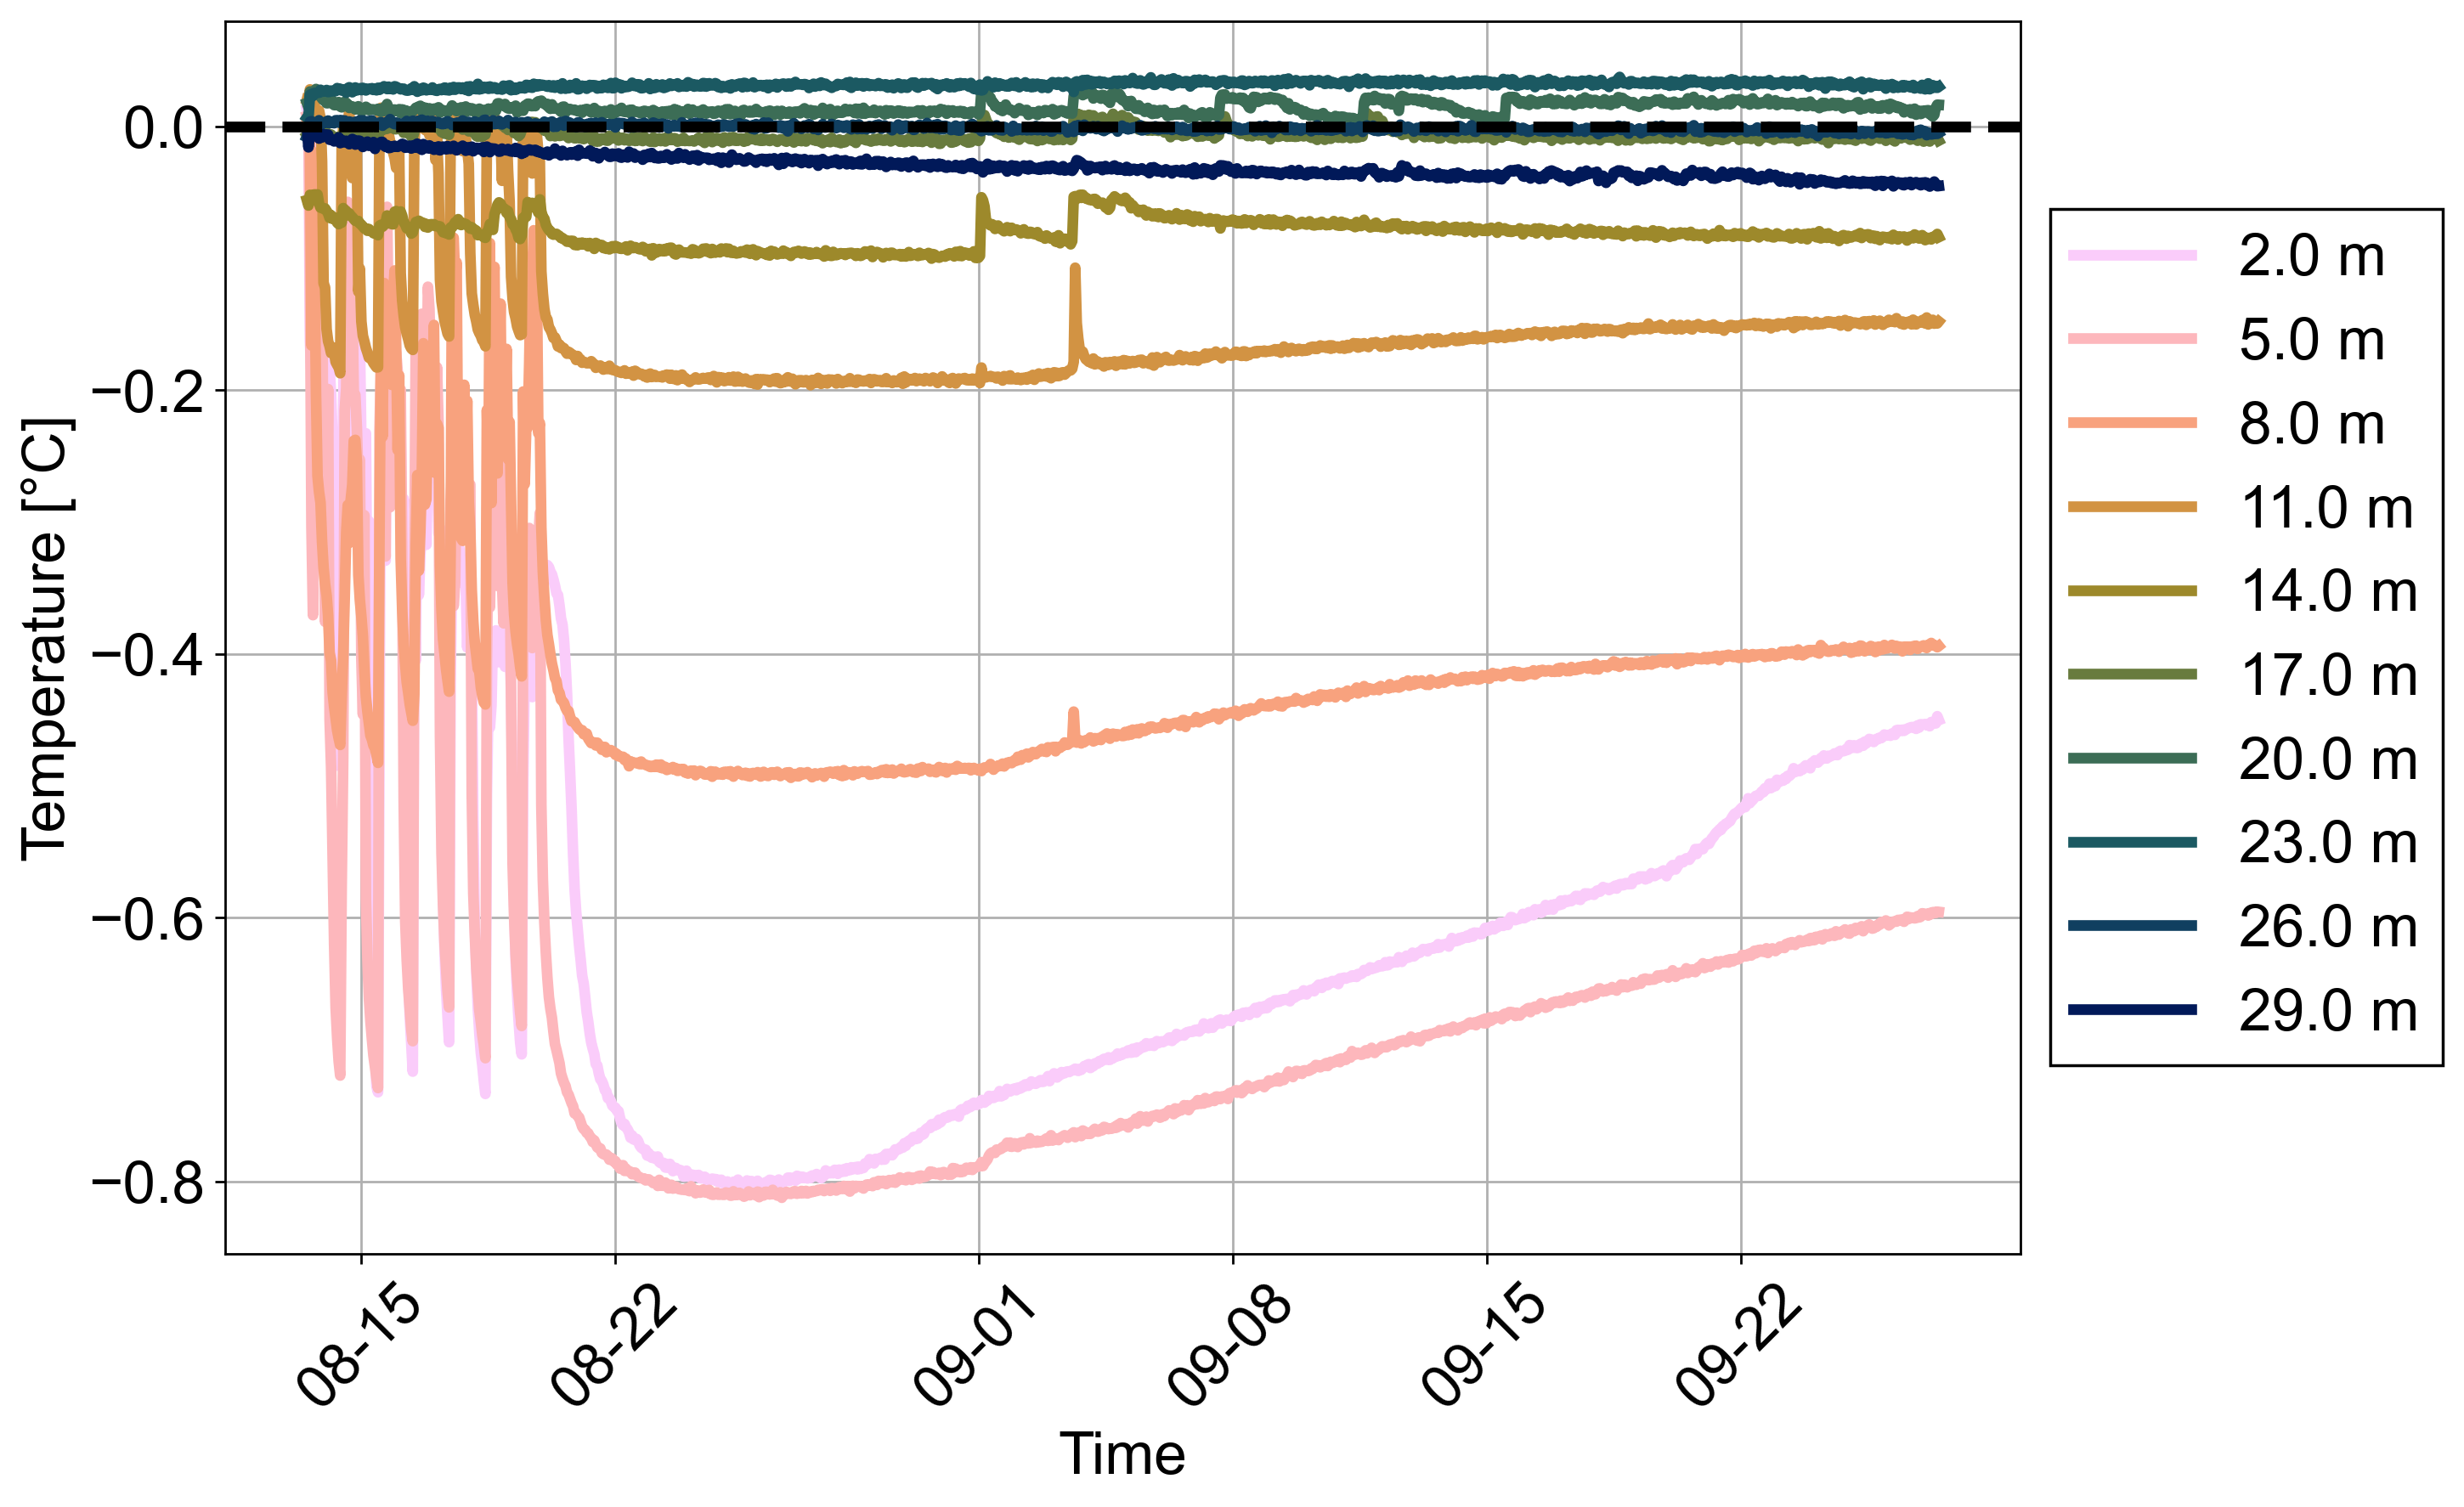

In [9]:
HL1G_plotter.plot_full_geoprecision_chain("13.08.2025 12:00:00","27.09.2025 12:00:00", A551FD_offsets, output_dir + "HL1G_chain_data.png", depth_file=depth_HL1G)

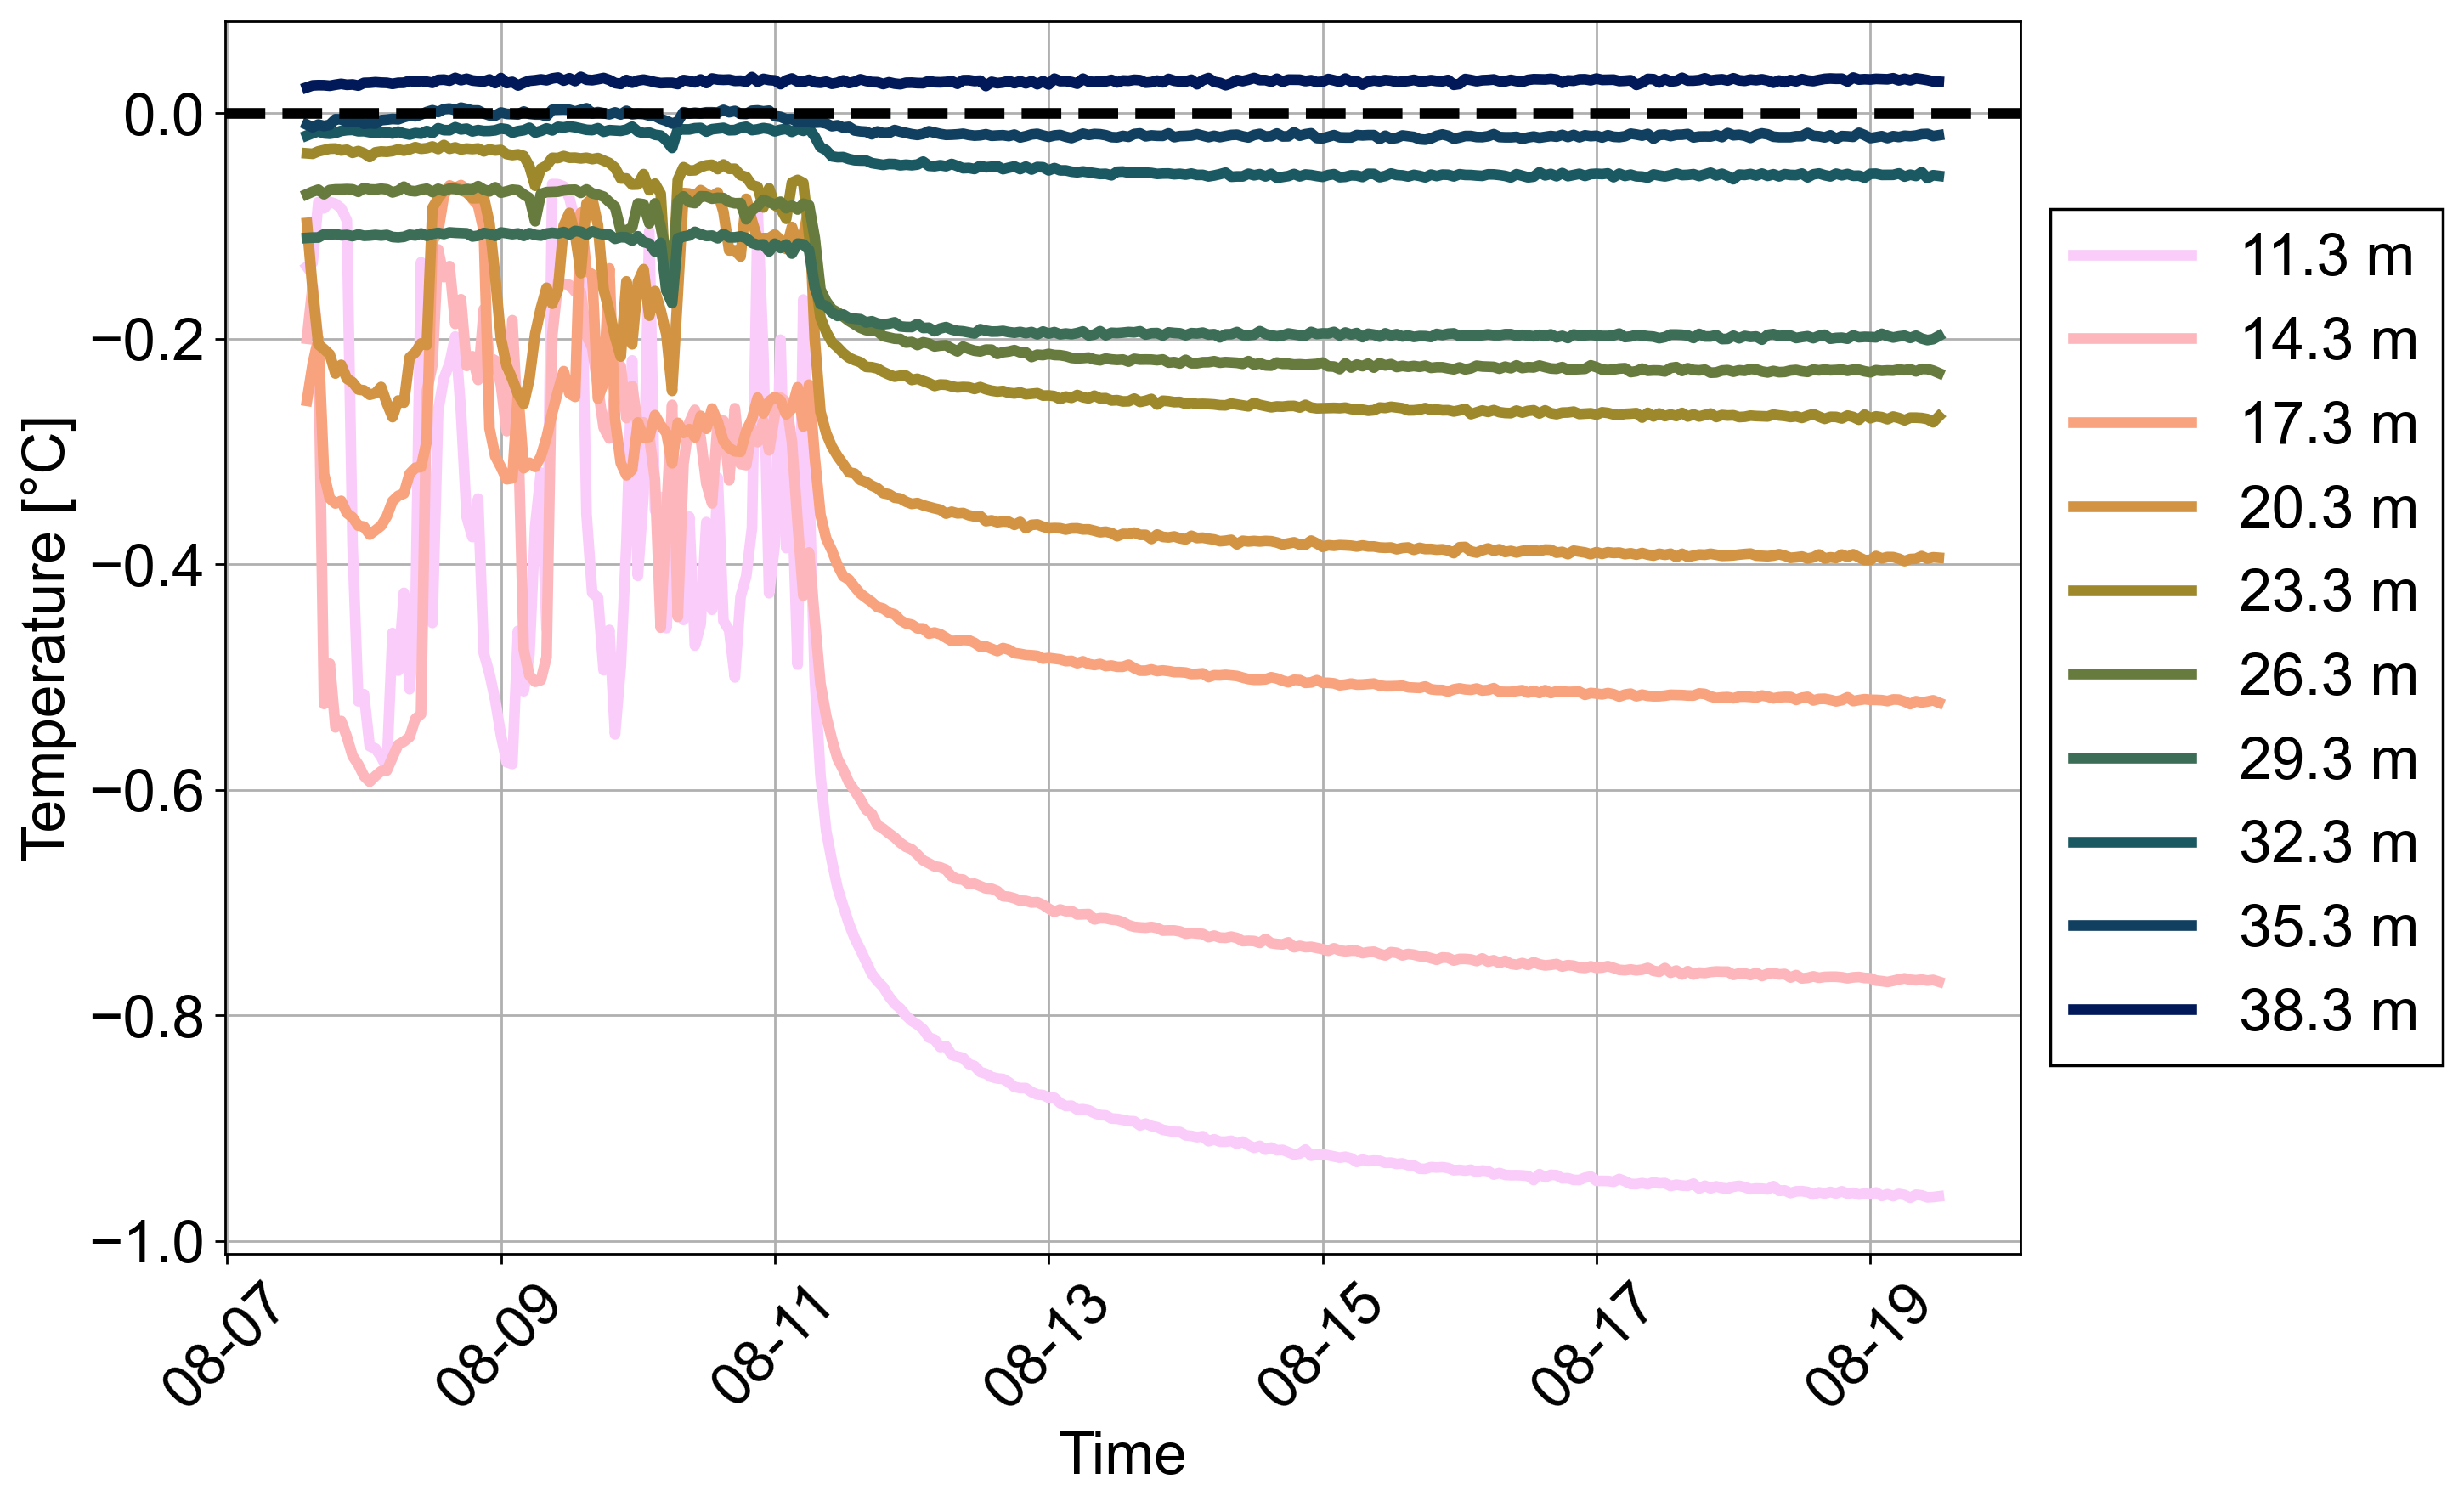

In [10]:
CH1G_plotter.plot_full_geoprecision_chain('07.08.2025 13:30:00','19.08.2025 13:00:00', A55201_offsets, output_dir + "CH1_full_chain.png", depth_file=depth_CH1G)

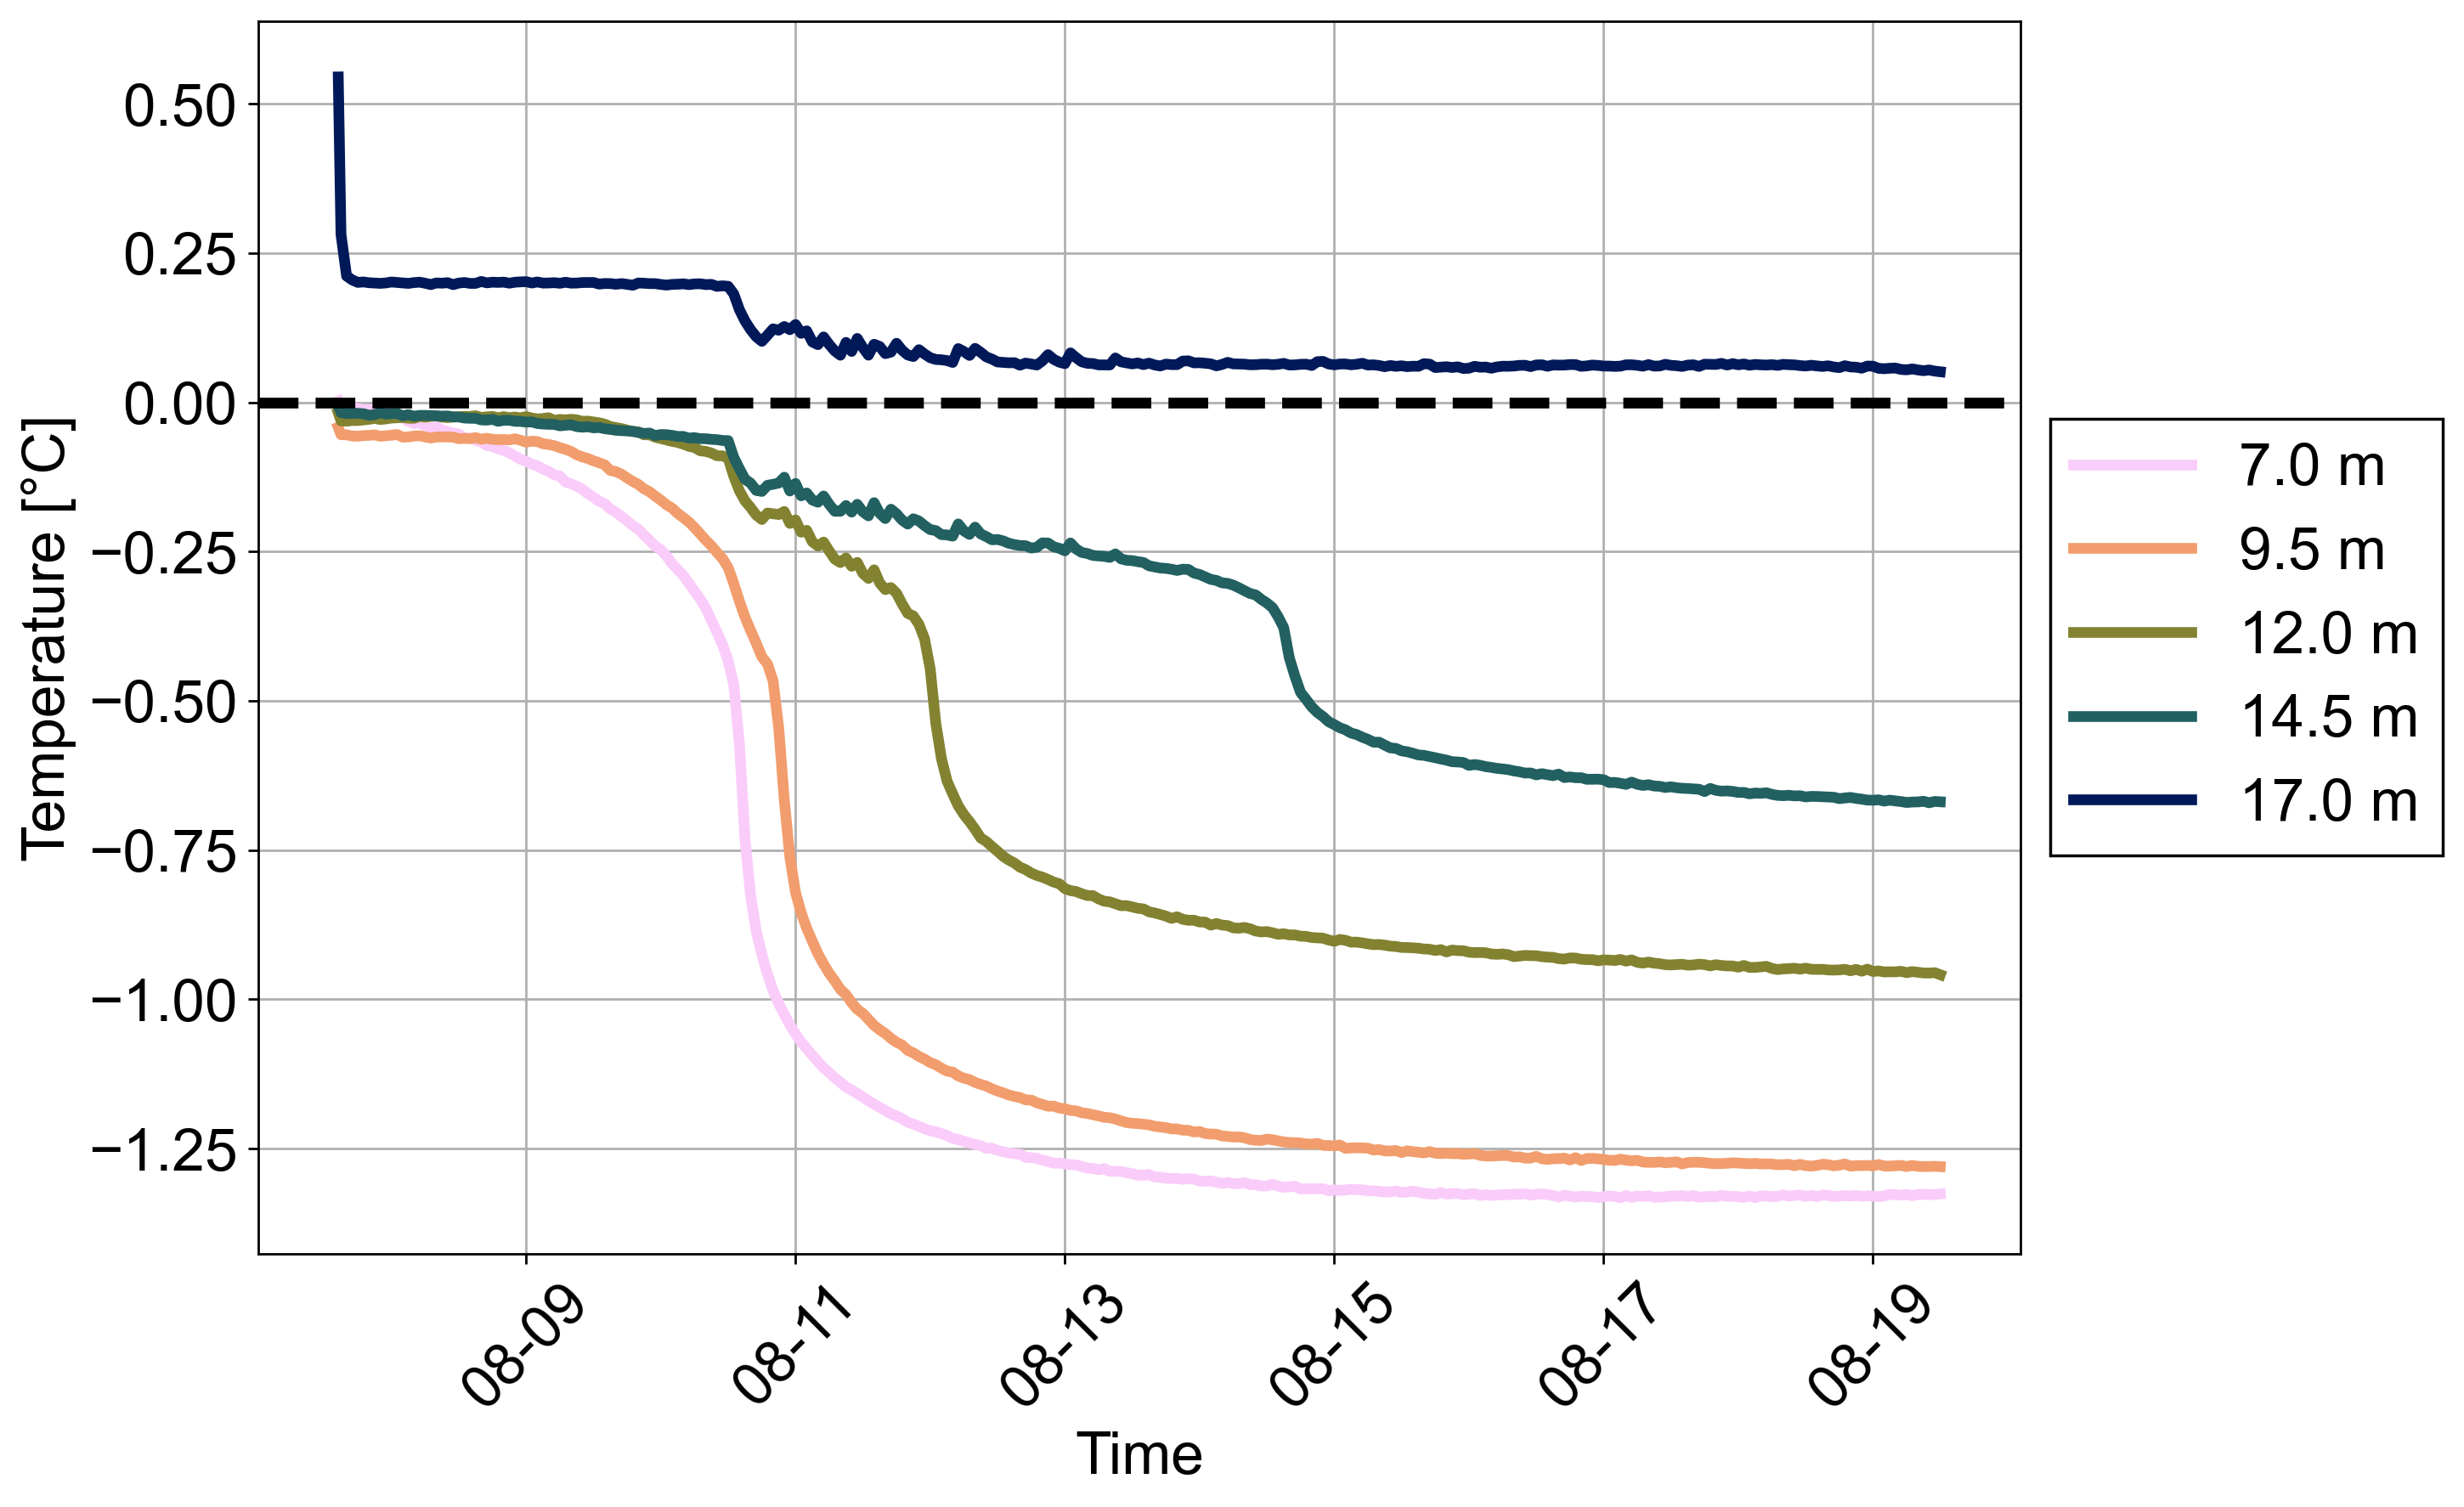

In [11]:
CH2G_plotter.plot_full_geoprecision_chain('07.08.2025 13:30:00','19.08.2025 13:00:00', A55202_offsets, output_dir + "CH2_full_chain.png", depth_file=depth_CH2G)

### Profiles

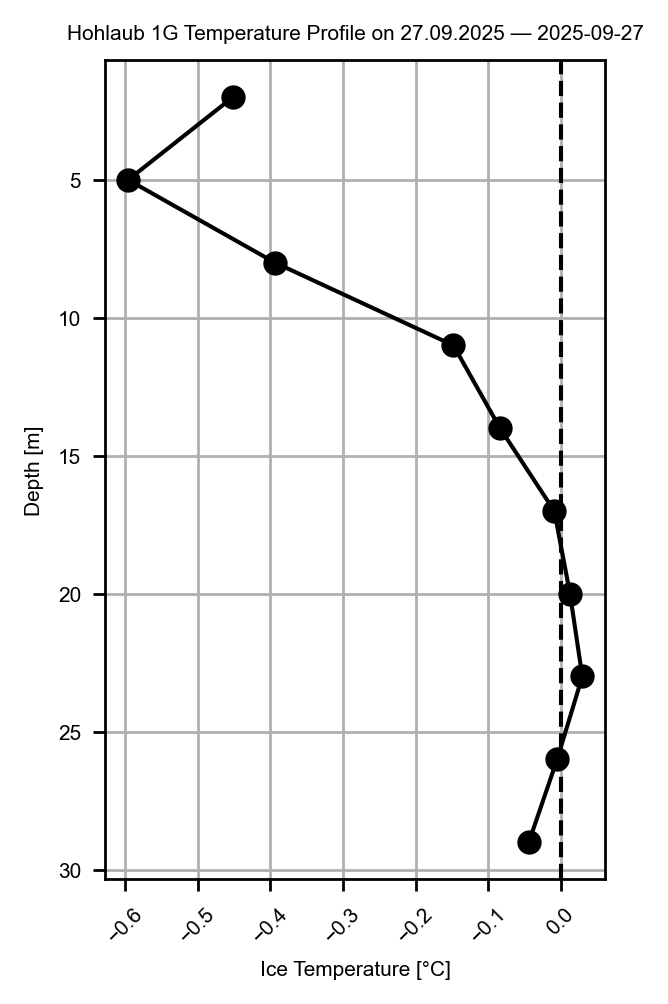

In [12]:
HL1G_plotter.plot_temperature_profile("27.09.2025", depth_file=depth_HL1G, offsets=A551FD_offsets, savepath=output_dir + "HL1G_temperature_profile.png", title="Hohlaub 1G Temperature Profile on 27.09.2025")

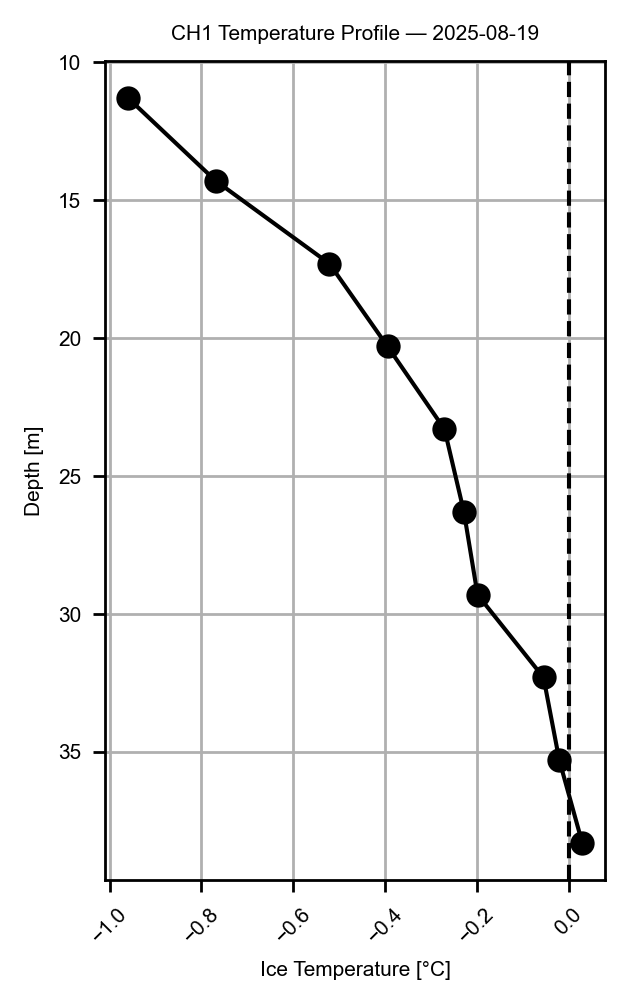

In [13]:
CH1G_plotter.plot_temperature_profile('19.08.2025', depth_file=depth_CH1G, offsets=A55201_offsets, savepath=output_dir + "CH1_temperature_profile.png", title="CH1 Temperature Profile")


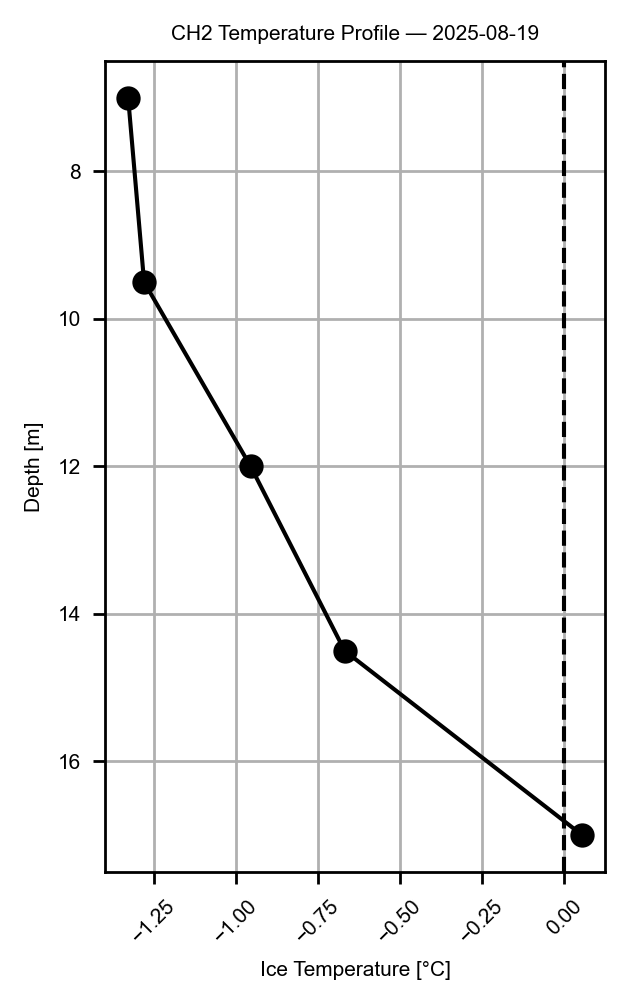

In [14]:
CH2G_plotter.plot_temperature_profile('19.08.2025', depth_file=depth_CH2G, offsets=A55202_offsets, savepath=output_dir + "CH2_temperature_profile.png", title="CH2 Temperature Profile")


In [15]:
## List containing file paths for all thermistor chain data per glacier

# Chessjengletscher
ch_file_paths = [A55201_dir, A55202_dir] 
CH = ThermistorDataPlotter(ch_file_paths, delimiter=',')

# Alphubelgletscher
ah_file_paths = [A551FE_dir, A55204_dir, A55205_dir] 
AH = ThermistorDataPlotter(ah_file_paths, delimiter=',')

# Hohlaubgletscher
hl_file_paths = [A551FD_dir, A55203_dir, A55200_dir] 
HL = ThermistorDataPlotter(hl_file_paths, delimiter=',')

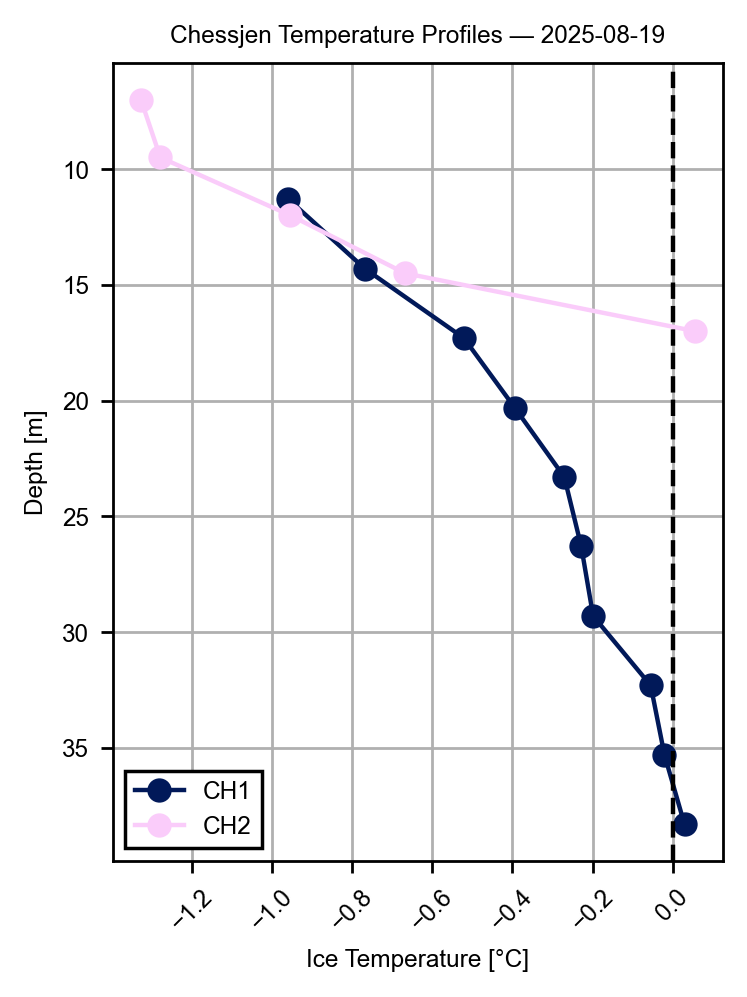

In [16]:
CH.plot_multiple_temperature_profiles(
    snapshot_time='19.08.2025',
    offsets_list=[A55201_offsets, A55202_offsets],
    depth_files=[depth_CH1G, depth_CH2G],
    labels=['CH1', 'CH2'],
    savepath=output_dir + "CH_profiles.png",
    title="Chessjen Temperature Profiles"
)

### Incorporate the Tynitag thermistor data into the profiles

In [17]:
# Tynitag thermistor ice temperature dir
tt_icetemp_dir = root_dir + 'NTC_tynitag/temperature_data/2024/'

# set glacier specific dirs
tt_CH_dirs  = [CH5TT_dir, CH6TT_dir]

# read depth files
depths_ch5tt = read_thermistor_depths(depth_CH5TT)
depths_ch6tt = read_thermistor_depths(depth_CH6TT)

# generate tynitag thermistor data object
tt_CH_data = ThermistorData(tt_CH_dirs, delimiter=',')

In [18]:
# read chain temperature offsets from CSV file
offsets_path_G = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/thermistor_calibration/corrected_chain_offsets.csv"
offsets_path_TT = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/calibration_data/all_logger_offsets.csv"
corrected_offsets_G = pd.read_csv(offsets_path_G, index_col='chain')
corrected_offsets_TT = pd.read_csv(offsets_path_TT)

In [19]:
## read out specific borehole data

# Chessjen
CH5TT_data = CH5TT.get_ntc_data_with_offsets('7', corrected_offsets_TT, aggregate='all') # average over entire period
CH6TT_data = CH6TT.get_ntc_data_with_offsets('8', corrected_offsets_TT, aggregate='all') # average over entire period

# Alphubel
AH4TT_data = AH4TT.get_ntc_data_with_offsets('13', corrected_offsets_TT, aggregate='all') # average over entire period
# AH5TT_data = AH5TT.get_ntc_data_with_offsets('5', corrected_offsets_TT, aggregate='all') # average over entire period
# AH6TT_data = AH6TT.get_ntc_data_with_offsets('6', corrected_offsets_TT, aggregate='all') # average over entire period

# Hohlaub
HL5TT_data = HL5TT.get_ntc_data_with_offsets('5', corrected_offsets_TT, aggregate='all') # average over entire period
HL6TT_data = HL6TT.get_ntc_data_with_offsets('6', corrected_offsets_TT, aggregate='all') # average over entire period

In [20]:
HL6TT_data

,Measurement,TIME,Black Probe Temperature,White Probe Temperature
0,1,2025-03-30 02:30:00,-0.397418,-1.097133


### Generate dataframes for tynitag data
- with offsets 
- without offsets

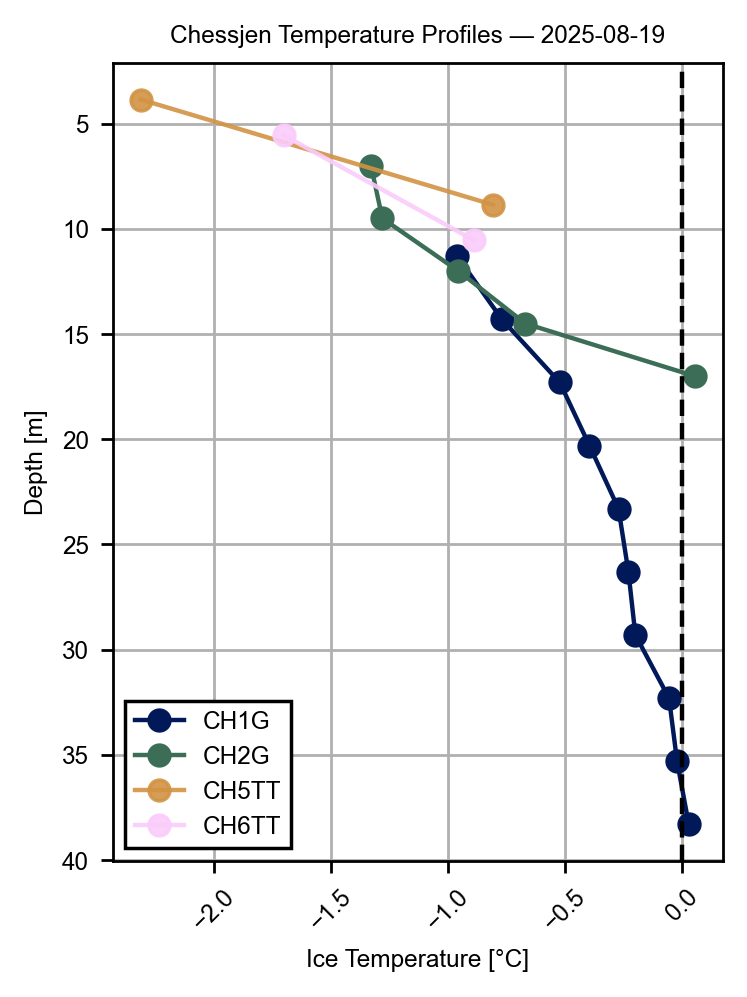

In [21]:
CH.plot_multiple_temperature_profiles(
    snapshot_time='19.08.2025',
    offsets_list=[A55201_offsets, A55202_offsets],
    depth_files=[depth_CH1G, depth_CH2G, depth_CH5TT, depth_CH6TT],
    labels=['CH1G', 'CH2G', 'CH5TT', 'CH6TT'],
    ntc_data_list=[CH5TT_data, CH6TT_data],
    savepath=output_dir + "CH_profiles.png",
    title="Chessjen Temperature Profiles"
)

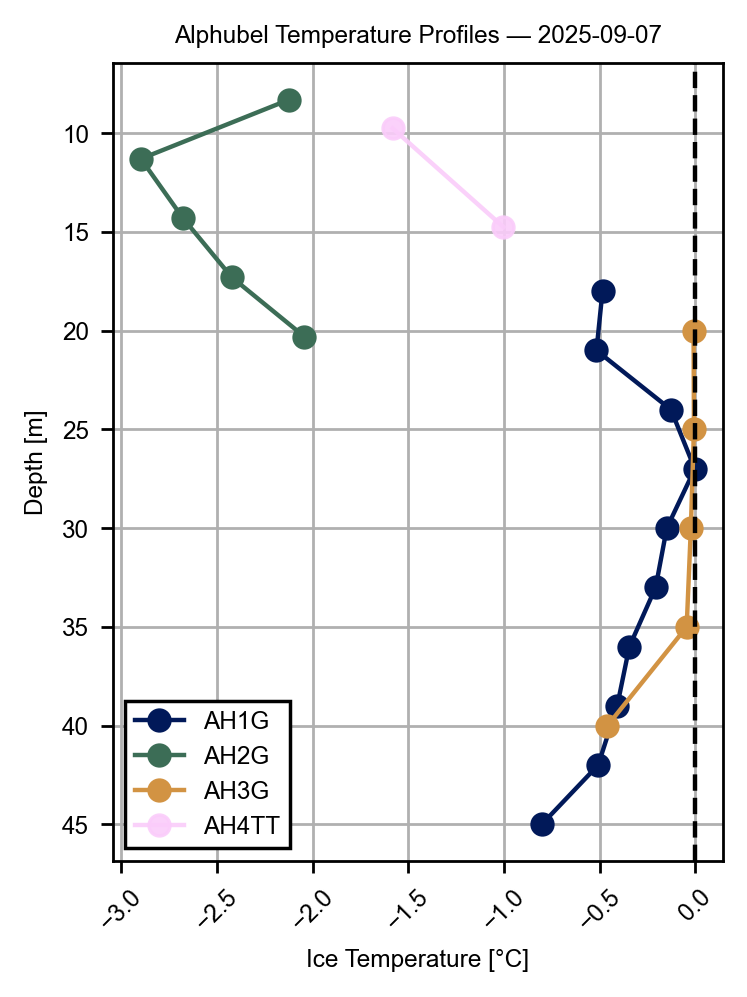

In [22]:
AH.plot_multiple_temperature_profiles(
    snapshot_time='07.09.2025',
    offsets_list=[A551FE_offsets, A55204_offsets, A55205_offsets],
    depth_files=[depth_AH1G, depth_AH2G, depth_AH3G, depth_AH4TT],
    labels=['AH1G', 'AH2G', 'AH3G', 'AH4TT'],
    ntc_data_list=[AH4TT_data],
    savepath=output_dir + "AH_profiles.png",
    title="Alphubel Temperature Profiles"
)


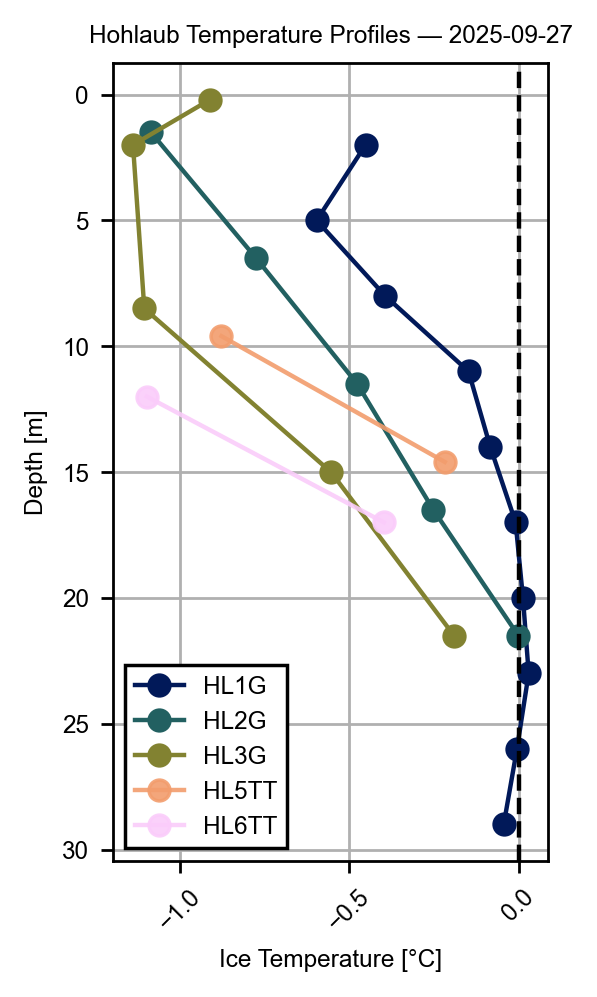

In [23]:
HL.plot_multiple_temperature_profiles(
    snapshot_time='27.09.2025',
    offsets_list=[A551FD_offsets, A55203_offsets, A55200_offsets],
    depth_files=[depth_HL1G, depth_HL2G, depth_HL3G, depth_HL5TT, depth_HL6TT],
    labels=['HL1G', 'HL2G', 'HL3G', 'HL5TT', 'HL6TT'],
    ntc_data_list=[HL5TT_data, HL6TT_data],
    savepath=output_dir + "HL_profiles.png",
    title="Hohlaub Temperature Profiles"
)